# Marketing Segmentation (Unsupervised) — Census Bureau Income Dataset

## Goal
Build an **unsupervised segmentation model** so marketing can tailor strategy by group (messaging, channel, offer).

This notebook:
1) loads + lightly cleans the data
2) builds a preprocessing pipeline for mixed numeric/categorical features
3) fits a clustering model (MiniBatchKMeans)
4) profiles segments and suggests how a retail client can use them

We may compute `y` (income > 50k) **only to interpret segments**, never to train the clustering model.


In [7]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# `display` is available in Jupyter, but not when executing as a plain Python script.
# This fallback makes the notebook runnable both ways.
try:
    from IPython.display import display
except Exception:
    display = print

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)


In [8]:
DATA_PATH = Path('census-bureau.data')
COLS_PATH = Path('census-bureau.columns')

def load_columns(cols_path: Path):
    cols = pd.read_csv(cols_path, header=None, names=['col'])['col'].tolist()
    cols = [c.strip() for c in cols if str(c).strip() != '']
    return cols

def load_data(data_path: Path, cols):
    df = pd.read_csv(
        data_path,
        header=None,
        names=cols,
        sep=",",
        engine='python',
        skipinitialspace=True,
    )
    obj_cols = df.select_dtypes(include='object').columns
    for c in obj_cols:
        df[c] = (
            df[c].astype(str)
                 .str.strip()
                 .replace({'?': np.nan, 'nan': np.nan})
        )
    # strip trailing periods
    for c in obj_cols:
        df[c] = df[c].str.replace(r'\.$', '', regex=True)
    return df

cols = load_columns(COLS_PATH)
df_raw = load_data(DATA_PATH, cols)
print('shape:', df_raw.shape)
df_raw.head()


shape: (199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000


In [9]:
# Label for interpretation only (NOT used in clustering)
mapping = {'- 50000': 0, '50000+': 1}
df_raw['y'] = df_raw['label'].map(mapping).astype(int)
print('base rate y=1:', float(df_raw['y'].mean()))


base rate y=1: 0.06205800834991455


## Feature set for segmentation
We use a compact and interpretable set aligned with marketing use cases (education, work status, occupation/industry, weeks worked, age, marital).

We exclude direct financial variables and high-cardinality detailed codes.


In [10]:
drop_cols = [
    'year',
    'wage per hour',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'detailed industry recode',
    'detailed occupation recode',
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt',
    'weight',
]

df = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).copy()

seg_num = [
    'age',
    'weeks worked in year',
    'num persons worked for employer',
]

seg_cat = [
    'education',
    'class of worker',
    'major occupation code',
    'major industry code',
    'marital stat',
    # fairness-sensitive; include only if acceptable
    'sex',
]

seg_num = [c for c in seg_num if c in df.columns]
seg_cat = [c for c in seg_cat if c in df.columns]

X_seg = df[seg_num + seg_cat].copy()
y = df['y'].astype(int).copy()

print('Seg features:', len(seg_num), 'num,', len(seg_cat), 'cat')
print('num:', seg_num)
print('cat:', seg_cat)
X_seg.head()


Seg features: 3 num, 6 cat
num: ['age', 'weeks worked in year', 'num persons worked for employer']
cat: ['education', 'class of worker', 'major occupation code', 'major industry code', 'marital stat', 'sex']


,age,weeks worked in year,num persons worked for employer,education,class of worker,major occupation code,major industry code,marital stat,sex
0,73,0,0,High school graduate,Not in universe,Not in universe,Not in universe or children,Widowed,Female
1,58,52,1,Some college but no degree,Self-employed-not incorporated,Precision production craft & repair,Construction,Divorced,Male
2,18,0,0,10th grade,Not in universe,Not in universe,Not in universe or children,Never married,Female
3,9,0,0,Children,Not in universe,Not in universe,Not in universe or children,Never married,Female
4,10,0,0,Children,Not in universe,Not in universe,Not in universe or children,Never married,Female


In [13]:
numeric_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=True)),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, seg_num),
        ('cat', categorical_tf, seg_cat),
    ],
    remainder='drop',
)


## Choose number of clusters (k)
We scan candidate k values using:
- inertia (elbow)
- silhouette score (higher is better)

We tune on a stratified sample for runtime.


In [14]:
# Keep runtime reasonable by sampling for k selection
train_size = 40000
if len(X_seg) <= train_size:
    X_sample = X_seg
else:
    X_sample, _X_unused, _y_sample, _y_unused = train_test_split(
        X_seg, y, train_size=train_size, random_state=42, stratify=y
    )

X_sample_t = preprocess.fit_transform(X_sample)
print('Transformed sample shape:', X_sample_t.shape)


Transformed sample shape: (40000, 64)


k=3: inertia=1.46e+05, silhouette=0.3429
k=4: inertia=1.39e+05, silhouette=0.3093
k=5: inertia=1.28e+05, silhouette=0.2776
k=6: inertia=1.23e+05, silhouette=0.2807
k=7: inertia=1.19e+05, silhouette=0.2578
k=8: inertia=1.16e+05, silhouette=0.2622
k=10: inertia=1.08e+05, silhouette=0.2399


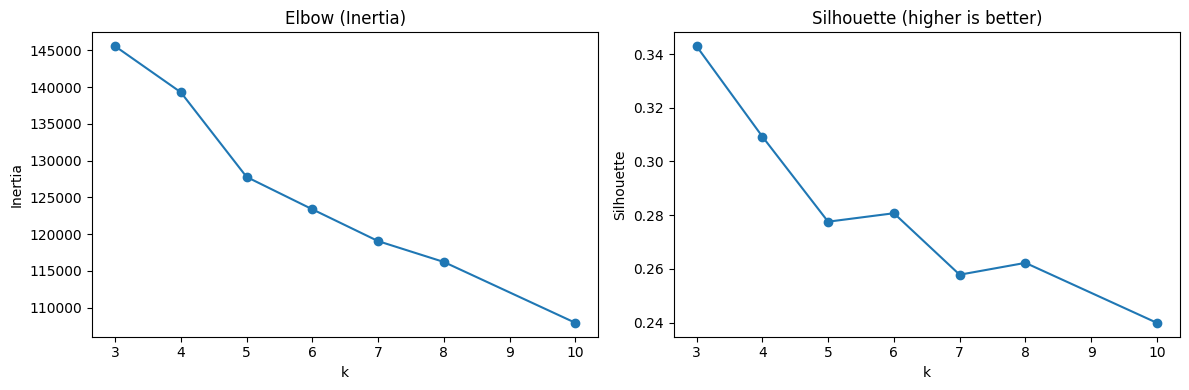

In [15]:
ks = [3, 4, 5, 6, 7, 8, 10]
inertias = []
silhs = []

rng = np.random.RandomState(42)
for k in ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=10)
    labels = km.fit_predict(X_sample_t)
    inertias.append(km.inertia_)

    # Silhouette is expensive; compute on subset
    n_silh = min(8000, X_sample_t.shape[0])
    idx = rng.choice(X_sample_t.shape[0], size=n_silh, replace=False)
    silh = silhouette_score(X_sample_t[idx], labels[idx], metric='euclidean')
    silhs.append(silh)
    print(f'k={k}: inertia={km.inertia_:.2e}, silhouette={silh:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker='o')
plt.title('Elbow (Inertia)')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(ks, silhs, marker='o')
plt.title('Silhouette (higher is better)')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()


## Fit final clustering model + assign segments
Pick a `K_FINAL` based on the k-scan, typically 5–8 for business interpretability.


In [16]:
K_FINAL = 6  # adjust after reviewing the k-scan above

cluster_pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('km', MiniBatchKMeans(n_clusters=K_FINAL, random_state=42, batch_size=4096, n_init=10)),
])

segments = cluster_pipe.fit_predict(X_seg)

df_seg = X_seg.copy()
df_seg['segment'] = segments
df_seg['y'] = y.values  # interpretation only

df_seg['segment'].value_counts().sort_index()


segment
0    18522
1    59002
2    24265
3    39165
4    19554
5    39015
Name: count, dtype: int64

## Segment profiling
We summarize each segment with:
- population share
- numeric means
- top categories per segment
- optional income rate (`y` mean) to interpret which segments skew high/low income


In [17]:
seg_sizes = df_seg['segment'].value_counts(normalize=True).rename('share')
num_summary = df_seg.groupby('segment')[seg_num].mean(numeric_only=True)
income_summary = df_seg.groupby('segment')['y'].mean().rename('income_rate')

summary = (
    seg_sizes.to_frame()
    .join(num_summary)
    .join(income_summary)
    .sort_index()
)
summary


,share,age,weeks worked in year,num persons worked for employer,income_rate
segment,,,,,
0,0.092831,45.125202,47.308228,1.399039,0.165317
1,0.295715,9.442731,0.400190,0.083556,0.000203
2,0.121615,41.753967,47.893386,2.911519,0.083454
3,0.196293,62.291153,0.973829,0.167216,0.017005
4,0.098004,24.744502,32.919710,2.809604,0.017285
5,0.195541,39.799821,48.188774,5.826580,0.160938


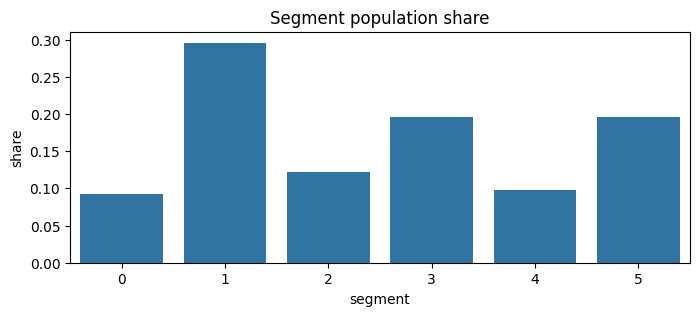

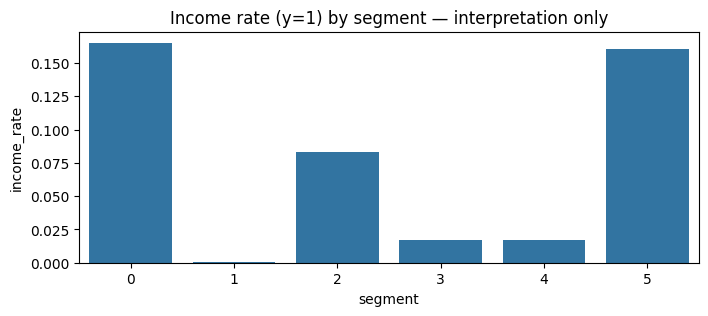

In [18]:
plt.figure(figsize=(8, 3))
sns.barplot(data=summary.reset_index(), x='segment', y='share')
plt.title('Segment population share')
plt.show()

plt.figure(figsize=(8, 3))
sns.barplot(data=summary.reset_index(), x='segment', y='income_rate')
plt.title('Income rate (y=1) by segment — interpretation only')
plt.show()


## Visualization: cluster separation in 2D
We project the high-dimensional one-hot feature space to 2 dimensions using **TruncatedSVD** (works well for sparse matrices).
If clusters are meaningful, you should see partial separation (not necessarily perfect separation).


In [ ]:
from sklearn.decomposition import TruncatedSVD

# Use a sample for visualization to keep plots responsive
viz_n = 20000
if len(X_seg) > viz_n:
    X_viz, _, seg_viz, _ = train_test_split(
        X_seg, df_seg['segment'], train_size=viz_n, random_state=42, stratify=df_seg['segment']
    )
else:
    X_viz = X_seg
    seg_viz = df_seg['segment']

X_viz_t = preprocess.transform(X_viz)
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_viz_t)

plot_df = pd.DataFrame({'svd1': X_2d[:,0], 'svd2': X_2d[:,1], 'segment': seg_viz.values})
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='svd1', y='svd2', hue='segment', palette='tab10', s=12, alpha=0.25, linewidth=0)
plt.title('2D projection of customers (TruncatedSVD on one-hot features)')
plt.legend(title='segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Visualization: business impact (lift + cumulative gains)
Even though clustering is unsupervised, we can quantify **impact** using `y` (income > 50k) **for interpretation only**.

Two useful plots for stakeholders:
- **Lift by segment**: which segments are most high-income-heavy
- **Cumulative gains**: if we target the best segments first, how many high-income customers do we capture?


In [ ]:
base_rate = float(df_seg['y'].mean())
impact = summary.copy()
impact['lift_vs_base'] = impact['income_rate'] / base_rate
impact = impact.reset_index().rename(columns={'index':'segment'})

plt.figure(figsize=(9,3))
ax = sns.barplot(data=impact, x='segment', y='lift_vs_base', palette='viridis')
plt.axhline(1.0, ls='--', c='black', lw=1)
plt.title(f'Lift vs baseline (baseline income rate={base_rate:.3f})')
plt.ylabel('Lift = segment income_rate / baseline')
plt.xlabel('Segment')
plt.tight_layout()
plt.show()


In [ ]:
# Cumulative gains: target best segments first
seg_stats = (
    df_seg.groupby('segment')
    .agg(n=('segment','size'), pos=('y','sum'), income_rate=('y','mean'))
    .sort_values('income_rate', ascending=False)
)
seg_stats['cum_pop'] = seg_stats['n'].cumsum() / seg_stats['n'].sum()
seg_stats['cum_pos'] = seg_stats['pos'].cumsum() / max(1, seg_stats['pos'].sum())

plt.figure(figsize=(6,4))
plt.plot(seg_stats['cum_pop'], seg_stats['cum_pos'], marker='o', label='Target by best segments')
plt.plot([0,1],[0,1],'--', label='Random targeting')
for seg, row in seg_stats.iterrows():
    plt.text(row['cum_pop'], row['cum_pos'], str(int(seg)), fontsize=9)
plt.title('Cumulative gains by segment (interpretation only)')
plt.xlabel('Cumulative population targeted')
plt.ylabel('Cumulative share of high-income captured')
plt.legend()
plt.tight_layout()
plt.show()

seg_stats


In [19]:
def top_levels_by_segment(df_seg: pd.DataFrame, col: str, top_n: int = 5) -> pd.DataFrame:
    rows = []
    for s, dfs in df_seg.groupby('segment'):
        vc = dfs[col].astype('object').fillna('Missing').value_counts(normalize=True).head(top_n)
        for level, share in vc.items():
            rows.append({
                'segment': int(s),
                'feature': col,
                'level': str(level),
                'share_within_segment': float(share),
            })
    return pd.DataFrame(rows).sort_values(['segment', 'share_within_segment'], ascending=[True, False])

for c in seg_cat:
    print('\n===', c, '===')
    display(top_levels_by_segment(df_seg, c, top_n=5))



=== education ===


,segment,feature,level,share_within_segment
0,0,education,High school graduate,0.337005
1,0,education,Some college but no degree,0.183188
2,0,education,Bachelors degree(BA AB BS),0.157218
3,0,education,Masters degree(MA MS MEng MEd MSW MBA),0.052586
4,0,education,Associates degree-occup /vocational,0.040492
5,1,education,Children,0.803735
6,1,education,9th grade,0.039405
7,1,education,10th grade,0.033423
8,1,education,Some college but no degree,0.028033
9,1,education,7th and 8th grade,0.027575



=== class of worker ===


,segment,feature,level,share_within_segment
0,0,class of worker,Self-employed-not incorporated,0.391156
1,0,class of worker,Private,0.372422
2,0,class of worker,Self-employed-incorporated,0.133355
3,0,class of worker,Local government,0.038333
4,0,class of worker,State government,0.025591
5,1,class of worker,Not in universe,0.991509
6,1,class of worker,Never worked,0.006491
7,1,class of worker,Local government,0.000712
8,1,class of worker,Self-employed-not incorporated,0.000525
9,1,class of worker,State government,0.000390



=== major occupation code ===


...

,segment,feature,level,share_within_segment
0,0,major industry code,Construction,0.170878
1,0,major industry code,Retail trade,0.141021
2,0,major industry code,Agriculture,0.097776
3,0,major industry code,Business and repair services,0.093726
4,0,major industry code,Other professional services,0.070997
5,1,major industry code,Not in universe or children,0.998000
6,1,major industry code,Education,0.000678
7,1,major industry code,Social services,0.000288
8,1,major industry code,Public administration,0.000271
9,1,major industry code,Agriculture,0.000203



=== marital stat ===


,segment,feature,level,share_within_segment
0,0,marital stat,Married-civilian spouse present,0.823237
1,0,marital stat,Divorced,0.084764
2,0,marital stat,Never married,0.046161
3,0,marital stat,Separated,0.017115
4,0,marital stat,Widowed,0.016737
5,1,marital stat,Never married,0.985390
6,1,marital stat,Married-civilian spouse present,0.007152
7,1,marital stat,Separated,0.002966
8,1,marital stat,Divorced,0.002119
9,1,marital stat,Married-A F spouse present,0.001186



=== sex ===


,segment,feature,level,share_within_segment
0,0,sex,Male,0.829662
1,0,sex,Female,0.170338
2,1,sex,Female,0.502610
3,1,sex,Male,0.497390
4,2,sex,Female,0.690583
5,2,sex,Male,0.309417
6,3,sex,Female,0.679740
7,3,sex,Male,0.320260
8,4,sex,Male,0.571034
9,4,sex,Female,0.428966


## How the retail client can use these segments
A simple activation playbook:

1) **Name each segment** based on the profiles above (e.g., “Full-time Professionals”, “Younger Part-time / Students”, “Self-employed Trades”).
2) Pick channel/message/offer by segment:
   - High weeks-worked + professional occupations → premium offers, upsell bundles, loyalty membership
   - Low weeks-worked / not-in-universe → low-cost channels + awareness + entry offers
   - Self-employed → small-business bundles, weekday targeting, B2B-style messaging
3) Export segment assignments to CRM and run A/B tests per segment.


In [20]:
# Export segment assignments (for downstream marketing activation)
out = df_raw[['label']].copy()
out['segment'] = segments
out.to_csv('segmentation_assignments.csv', index=False)
print('Wrote segmentation_assignments.csv')


Wrote segmentation_assignments.csv
